# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 7.5 MB/s eta 0:00:00


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [6]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


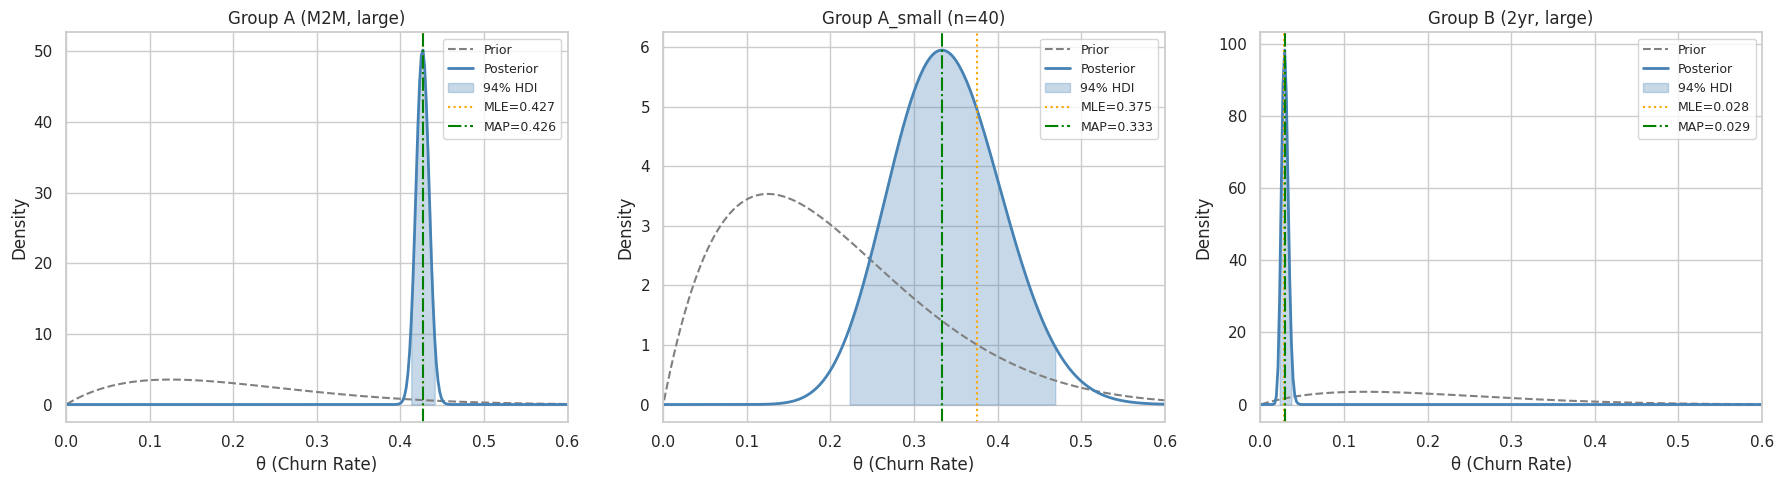

In [7]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    # PDFs
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf  = beta_dist.pdf(theta_range, alpha_post, beta_post)

    # Estimates
    mle = k / n
    map_est = (alpha_post - 1) / (alpha_post + beta_post - 2)

    # 94% HDI
    hdi_low, hdi_high = beta_dist.ppf([0.03, 0.97], alpha_post, beta_post)

    ax.plot(theta_range, prior_pdf, label='Prior', color='gray', linestyle='--')
    ax.plot(theta_range, post_pdf, label='Posterior', color='steelblue', lw=2)
    ax.fill_between(theta_range, 0, post_pdf,
                    where=(theta_range >= hdi_low) & (theta_range <= hdi_high),
                    color='steelblue', alpha=0.3, label='94% HDI')

    ax.axvline(mle, color='orange', ls=':', label=f'MLE={mle:.3f}')
    ax.axvline(map_est, color='green', ls='-.', label=f'MAP={map_est:.3f}')

    ax.set_title(name)
    ax.set_xlabel('θ (Churn Rate)')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 0.6)
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [8]:
MC_SAMPLES = 10_000
np.random.seed(42)

# Sample from both posteriors
# Group A (Month-to-month): posterior parameters are (alpha_prior + k_A, beta_prior + n_A - k_A)
post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)

# Group B (Two-year): posterior parameters are (alpha_prior + k_B, beta_prior + n_B - k_B)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)

# Compute P(θ_A > θ_B)
p_A_greater = np.mean(post_A_samples > post_B_samples)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")

P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
Ans. For Group A_small, the pull is ~0.0417, while for Group B (large), it is significantly smaller (~0.0005). The pull is larger for the small group because the likelihood is less 'peaked'. In Bayesian terms, the relative weight of the prior (Beta(2,8) acts like 10 'pseudo-observations') is much higher when $n=40$ than when $n=1695$.

<br>

2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
<br>
Ans. I would present the **MAP estimate** (or better yet, the full posterior distribution with the HDI).
   *   **MLE** is purely data-driven but overfits to small samples (high variance).
   *   **MAP** incorporates domain knowledge (prior) to regularize the estimate, preventing 'wild' conclusions from small datasets.
   *   **Full Bayes (Posterior)** provides the HDI, communicating our *uncertainty* clearly, which MLE/MAP do not natively do.
<br>

3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?
<br>
Ans. The prior becomes essentially irrelevant when the number of observations $n$ is large enough that the pseudo-counts of the prior (10) are negligible. Typically, when $n > 1000$, the MAP and MLE converge to within 1% of each other for most churn rates.



### ✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. **Prior pull (|MAP − MLE|):** For Group A_small, the pull is ~0.0417, while for Group B (large), it is significantly smaller (~0.0005). The pull is larger for the small group because the likelihood is less 'peaked'. In Bayesian terms, the relative weight of the prior (Beta(2,8) acts like 10 'pseudo-observations') is much higher when $n=40$ than when $n=1695$.

2. **Recommendation for VP:** I would present the **MAP estimate** (or better yet, the full posterior distribution with the HDI).
   *   **MLE** is purely data-driven but overfits to small samples (high variance).
   *   **MAP** incorporates domain knowledge (prior) to regularize the estimate, preventing 'wild' conclusions from small datasets.
   *   **Full Bayes (Posterior)** provides the HDI, communicating our *uncertainty* clearly, which MLE/MAP do not natively do.

3. **Irrelevance threshold:** The prior becomes essentially irrelevant when the number of observations $n$ is large enough that the pseudo-counts of the prior (10) are negligible. Typically, when $n > 1000$, the MAP and MLE converge to within 1% of each other for most churn rates.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [ ]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    # YOUR CODE HERE
    # Hint: if churn_label == 1, increment alpha; else increment beta
    raise NotImplementedError("Implement update_posterior")


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")


### Q5 — Run sequential update and plot posterior evolution


In [ ]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}

raise NotImplementedError("Run sequential updates and record history at snapshots")

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


In [ ]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# YOUR CODE HERE
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

raise NotImplementedError("Compute P(θ > 0.25) at each n from 1 to 500")

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


In [ ]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
counts           = None   # np.array of shape (3,) — counts per category
posterior_alpha  = None   # prior_alpha + counts
raise NotImplementedError("Compute Dirichlet posterior parameters")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # YOUR CODE HERE: plot the marginal Beta(a_j, b_j) posterior for this category
    raise NotImplementedError("Plot marginal Beta posterior for each contract category")
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories

new_alpha_4cat = None   # append pseudocount 1 to posterior_alpha
raise NotImplementedError("Add 4th category with pseudocount=1 and compute its marginal posterior")

print("Posterior for unseen 'Biannual' category:")
# Print its posterior mean and compare to a category with many observations


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

> *Your answer:*


---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
mu_2d    = None   # np.mean over axis=0
Sigma_2d = None   # np.cov(X_2d.T)
rho      = None   # correlation coefficient
raise NotImplementedError("Compute mu_2d, Sigma_2d, rho")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")


In [ ]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
raise NotImplementedError("Plot scatter + confidence ellipses")
plt.tight_layout(); plt.show()


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [ ]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = None   # μ_1|2
cond_var  = None   # σ²_1|2
cond_std  = None   # sqrt(cond_var)
raise NotImplementedError("Compute conditional mean and variance using the formula above")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


### Q10 — 3D Covariance and Condition Number


In [ ]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d         = None
kappa            = None
Sigma_marginal   = None   # upper-left 2×2 submatrix of Sigma_3d
max_diff         = None   # max absolute difference vs Sigma_2d
raise NotImplementedError("Compute Sigma_3d, kappa, and marginalise")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*


---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [ ]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = None
raise NotImplementedError("Define dag_edges as a list of (parent, child) tuples")

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


In [ ]:
infer = VariableElimination(dag)

# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = None
p_churn_m2m_bn = None
raise NotImplementedError("Compute P(Churn | Contract='Month-to-month') via VE")

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


In [ ]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = None
raise NotImplementedError("Compute P(Contract | Churn='1') via VE")
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
YOUR DRAWING HERE (ASCII DAG)
```

**Observation set E where both models agree:** *(YOUR ANSWER)*

**Observation set E where models disagree:** *(YOUR ANSWER)*

**Which causal story is more consistent with W5 SHAP findings?** *(YOUR ANSWER)*


### Q13 — Markov Random Field: undirected model


In [ ]:
# YOUR CODE HERE
# Build a DiscreteMarkovNetwork with the same 4 variables (undirected edges)
# Define pairwise DiscreteFactor objects from joint empirical frequencies
# Run BeliefPropagation to compute P(Churn)
# Compare to the BN's P(Churn) and the empirical base rate
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges (same variables, no direction)
mrf_edges = None   # YOUR CODE HERE
mrf       = None   # DiscreteMarkovNetwork(mrf_edges)
raise NotImplementedError("Build and query the DiscreteMarkovNetwork")

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN    differs from the raw empirical proportion. Name the **two specific reasons** for    this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that    the MRF cannot? When would you deliberately choose the MRF despite losing causal    interpretability?

> *Your answer:*


---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [ ]:
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25

from statsmodels.datasets import co2
df_co2 = None   # YOUR CODE HERE
t      = None   # YOUR CODE HERE
y      = None   # df_co2['co2'].values
raise NotImplementedError("Load Mauna Loa dataset in 3 lines")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | *(your description)* | *(your kernel)* | *(why this kernel)* |
| Seasonal | *(your description)* | *(your kernel)* | *(why this kernel)* |
| Noise | *(your description)* | *(your kernel)* | *(why this kernel)* |

> *Fill in the table above before writing any code.*


In [ ]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# YOUR CODE HERE — construct the composite kernel
# k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
# k_seasonal = RBF(...) * ExpSineSquared(..., periodicity=1.0, periodicity_bounds='fixed')
# k_noise    = WhiteKernel(...)
# kernel     = k_trend + k_seasonal + k_noise
k_trend    = None
k_seasonal = None
k_noise    = None
kernel     = None
raise NotImplementedError("Define the composite kernel")

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
# YOUR CODE HERE: fit gp on (t_train, y_train)
raise NotImplementedError("Fit the GP")

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


In [ ]:
# YOUR CODE HERE — plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = None, None   # YOUR CODE HERE
raise NotImplementedError("Predict over full range and plot")

fig, ax = plt.subplots(figsize=(15, 6))
# YOUR PLOT CODE HERE
plt.tight_layout(); plt.show()


### Q16 — Gap experiment


In [ ]:
# YOUR CODE HERE
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap

gap_lo, gap_hi = 15.0, 17.0

# YOUR CODE HERE: create t_gap_tr and y_gap_tr with the gap removed
t_gap_tr = None
y_gap_tr = None
raise NotImplementedError("Remove gap from training data and refit GP")

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
# YOUR CODE HERE: fit gp_gap on (t_gap_tr, y_gap_tr)
raise NotImplementedError("Fit gp_gap")

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
# YOUR PLOT CODE HERE — show the gap region, credible bands, and training data
raise NotImplementedError("Plot gap experiment results")
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")


### Q17 — Extrapolation and the model confidence boundary


In [ ]:
# YOUR CODE HERE
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# YOUR CODE HERE: compute band widths at +5, +10, +15 years
for years in [5, 10, 15]:
    # Find the index corresponding to t_last + years
    raise NotImplementedError("Compute band width at each extrapolation horizon")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

fig, ax = plt.subplots(figsize=(14, 5))
# YOUR PLOT CODE HERE
raise NotImplementedError("Plot extrapolation with credible bands")
plt.tight_layout(); plt.show()


✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [ ]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> *Your answer (2-3 sentences):*


In [ ]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # YOUR CODE HERE
    # intercept: Normal(0, 5)
    # beta:      Normal(0, 2), shape=n_features
    # mu:        sigmoid(intercept + dot(X_tr_scaled, beta))
    # y_obs:     Bernoulli(p=mu, observed=y_tr_mc)
    intercept = None
    beta      = None
    raise NotImplementedError("Specify the Bayesian logistic regression model")

    mu    = pm.Deterministic('mu', pm.math.sigmoid(
        intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    # YOUR CODE HERE: sample with draws=2000, tune=1000, chains=4, target_accept=0.90
    idata = None
    raise NotImplementedError("Sample with pm.sample()")

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))


### Q19 — Convergence diagnostics


In [ ]:
# YOUR CODE HERE
# 1. Plot trace plots with az.plot_trace() for intercept and beta
# 2. Report R̂ and bulk-ESS for each coefficient
# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

raise NotImplementedError("Run convergence diagnostics")

# Print the flagged parameters
print("Flagged parameters (R̂ > 1.01 or ESS < 400):")
# YOUR CODE HERE


### Q20 — Prior sensitivity check


In [ ]:
# YOUR CODE HERE
# 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# 3. Decide: are the posteriors prior-robust or does the prior dominate?

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# YOUR CODE HERE: plot the two posteriors overlaid
fig, ax = plt.subplots(figsize=(10, 4))
raise NotImplementedError("Plot prior sensitivity comparison")
plt.tight_layout(); plt.show()


### Q21 — Posterior analysis and frequentist comparison


In [ ]:
# YOUR CODE HERE
# 1. Extract posterior samples for Contract_Month-to-month coefficient
# 2. Compute 94% HDI using az.hdi()
# 3. Run sklearn LogisticRegression(C=1e6) and get the MLE coefficient
# 4. Report both and explain the philosophical difference

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post  = None   # idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = None   # az.hdi(beta_post, prob=0.94)
post_mean  = None
post_std   = None
raise NotImplementedError("Extract posterior samples and compute HDI")

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = None   # extract the coefficient at contract_idx
raise NotImplementedError("Fit frequentist logistic regression and extract coefficient")

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")


### Q22 — Save the MCMC trace


In [ ]:
# YOUR CODE HERE
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
# YOUR CODE HERE: pickle.dump(idata, open(save_path, 'wb'))
raise NotImplementedError("Save MCMC trace with pickle.dump()")
print(f"✅ MCMC trace saved to '{save_path}'")


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.

> *Your answer:*


---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
